# foundations/02: CRN Motif Library

This notebook covers the `crn_surrogate.data.generation` sub-package, which provides a library of biologically-motivated CRN motifs for generating diverse training datasets.

**Contents:**
1. Propensity Types — Hill, HillRepression, HillActivationRepression, SubstrateInhibition
2. Motif Catalogue — 8 canonical motifs with factories
3. Example Trajectories — one SSA ensemble per motif, 2×4 grid
4. Parameter Sampling — ParameterSampler, log-uniform sampling
5. Viability Curation — ViabilityFilter, 6 criteria

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

from _shared.plotting import setup_style, plot_trajectory_ensemble

setup_style()

import torch
import numpy as np
import matplotlib.pyplot as plt

TAB10 = plt.rcParams["axes.prop_cycle"].by_key()["color"]

## 1. Propensity Types

The library provides several kinetic propensity functions beyond the basic mass-action rate law:

| Type | Formula | Use case |
|------|---------|----------|
| `hill` | V_max · X^n / (K^n + X^n) | Sigmoidal activation |
| `hill_repression` | k_max / (1 + (X/K)^n) | Gene repression, negative feedback |
| `hill_activation_repression` | k_max · Hill_act(X_a) · Hill_rep(X_r) | Incoherent feedforward loop |
| `substrate_inhibition` | V_max · S / (K_m + S + S²/K_i) | Enzyme inhibited by excess substrate |
| `enzyme_michaelis_menten` | k_cat · E · S / (K_m + S) | Explicit enzyme catalysis |

These complement the existing `mass_action` and `constant_rate` propensities.

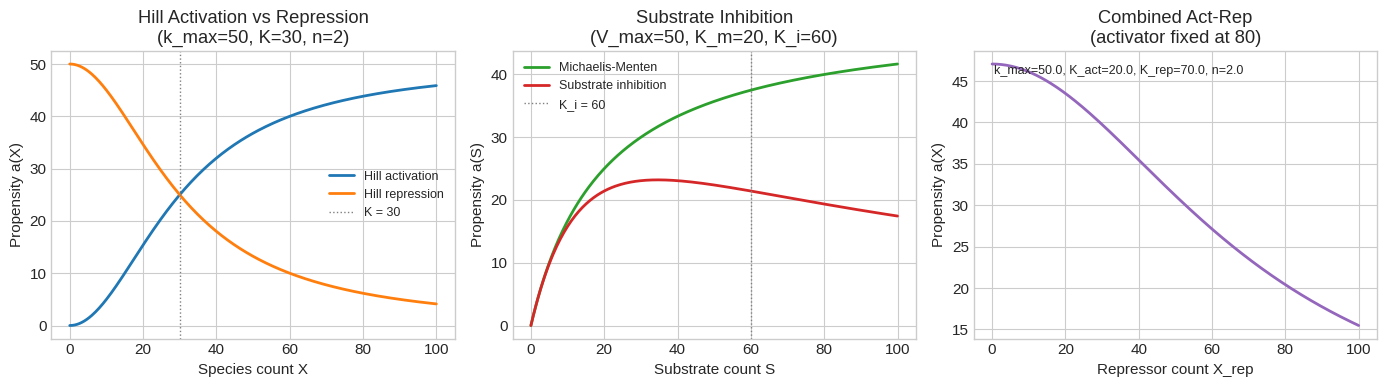

In [2]:
import torch
from crn_surrogate.crn.propensities import (
    hill_repression, hill_activation_repression, substrate_inhibition, hill,
)

x_vals = torch.linspace(0, 100, 300)

# Hill activation vs repression
p_act = hill(v_max=50.0, k_m=30.0, hill_coefficient=2.0, species_index=0)
p_rep = hill_repression(k_max=50.0, k_half=30.0, hill_coefficient=2.0, species_index=0)

act_rates = torch.stack([p_act(torch.tensor([x]), 0.0) for x in x_vals])
rep_rates = torch.stack([p_rep(torch.tensor([x]), 0.0) for x in x_vals])

# Substrate inhibition vs simple Michaelis-Menten
p_sub_inh = substrate_inhibition(v_max=50.0, k_m=20.0, k_i=60.0, species_index=0)
mm_rates = 50.0 * x_vals / (20.0 + x_vals + 1e-8)
sub_rates = torch.stack([p_sub_inh(torch.tensor([x]), 0.0) for x in x_vals])

# Combined activation-repression: fix activator at 80, sweep repressor
k_max, k_act, n_act, k_rep, n_rep = 50.0, 20.0, 2.0, 70.0, 2.0
p_combined = hill_activation_repression(
    k_max=k_max, k_act=k_act, n_act=n_act, activator_index=0,
    k_rep=k_rep, n_rep=n_rep, repressor_index=1,
)
rep_sweep = torch.linspace(0, 100, 300)
combined_rates = torch.stack([
    p_combined(torch.tensor([80.0, r.item()]), 0.0)
    for r in rep_sweep
])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(x_vals, act_rates.detach(), color=TAB10[0], lw=2, label="Hill activation")
axes[0].plot(x_vals, rep_rates.detach(), color=TAB10[1], lw=2, label="Hill repression")
axes[0].axvline(30, color="gray", linestyle=":", lw=1, label="K = 30")
axes[0].set_xlabel("Species count X")
axes[0].set_ylabel("Propensity a(X)")
axes[0].set_title("Hill Activation vs Repression\n(k_max=50, K=30, n=2)")
axes[0].legend(fontsize=9)

axes[1].plot(x_vals, mm_rates.detach(), color=TAB10[2], lw=2, label="Michaelis-Menten")
axes[1].plot(x_vals, sub_rates.detach(), color=TAB10[3], lw=2, label="Substrate inhibition")
axes[1].axvline(60, color="gray", linestyle=":", lw=1, label="K_i = 60")
axes[1].set_xlabel("Substrate count S")
axes[1].set_ylabel("Propensity a(S)")
axes[1].set_title("Substrate Inhibition\n(V_max=50, K_m=20, K_i=60)")
axes[1].legend(fontsize=9)

axes[2].plot(rep_sweep, combined_rates.detach(), color=TAB10[4], lw=2)
axes[2].set_xlabel("Repressor count X_rep")
axes[2].set_ylabel("Propensity a(X)")
axes[2].set_title("Combined Act-Rep\n(activator fixed at 80)")
axes[2].text(0.05, 0.92, f"k_max={k_max}, K_act={k_act}, K_rep={k_rep}, n={n_rep}",
             transform=axes[2].transAxes, fontsize=9)

plt.tight_layout()
plt.show()

## 2. Motif Catalogue

The generation library includes 8 canonical network motifs drawn from the systems biology literature. Each is implemented as a `MotifFactory` that returns a typed CRN given a parameter dataclass.

| Motif | Species | Reactions | Key dynamics |
|-------|---------|-----------|-------------|
| Birth-death | 1 | 2 | Poisson stationary distribution |
| Auto-catalysis | 1 | 3 | Positive feedback, bistable regime |
| Negative autoregulation | 1 | 2 | Noise reduction, faster response |
| Toggle switch | 2 | 4 | Bistability (Gardner-Collins) |
| Enzymatic catalysis | 4 | 5 | Michaelis-Menten with explicit complex |
| Incoherent FFL | 3 | 6 | Pulse/adaptation response |
| Repressilator | 3 | 6 | Sustained oscillations (Elowitz & Leibler) |
| Substrate inhibition | 2 | 3 | Non-monotone dose-response |

In [3]:
from crn_surrogate.data.generation.motifs import (
    BirthDeathFactory, AutoCatalysisFactory, NegativeAutoregulationFactory,
    ToggleSwitchFactory, EnzymaticCatalysisFactory, IncoherentFeedforwardFactory,
    RepressilatorFactory, SubstrateInhibitionMotifFactory,
)

factories = [
    BirthDeathFactory(),
    AutoCatalysisFactory(),
    NegativeAutoregulationFactory(),
    ToggleSwitchFactory(),
    EnzymaticCatalysisFactory(),
    IncoherentFeedforwardFactory(),
    RepressilatorFactory(),
    SubstrateInhibitionMotifFactory(),
]

print(f"{'Motif':<30} {'Species':<25} {'n_rxn':>5}")
print("-" * 65)
for f in factories:
    print(f"  {f.motif_type.value:<28} {str(f.species_names):<25} {f.n_reactions:>5}")

Motif                          Species                   n_rxn
-----------------------------------------------------------------
  birth_death                  ('A',)                        2
  auto_catalysis               ('A',)                        3
  negative_autoregulation      ('A',)                        2
  toggle_switch                ('A', 'B')                    4
  enzymatic_catalysis          ('S', 'E', 'C', 'P')          5
  incoherent_feedforward       ('X', 'Y', 'Z')               6
  repressilator                ('A', 'B', 'C')               6
  substrate_inhibition         ('S', 'P')                    3


## 3. Example Trajectories

We simulate one SSA ensemble per motif using fixed parameter values chosen to produce characteristic dynamics. The 2×4 grid shows the qualitative behavior that the model must learn to approximate.

In [4]:
from crn_surrogate.simulation import GillespieSSA, Trajectory

ssa = GillespieSSA()

T_MAX = 80.0
N_TRAJ = 20

# Fixed parameter values chosen for characteristic dynamics
fixed_params = [
    {"k_prod": 10.0, "k_deg": 0.2},
    {"k_basal": 1.0, "k_cat": 0.05, "k_deg": 0.1},
    {"k_max": 40.0, "k_half": 20.0, "n_hill": 2.5, "k_deg": 0.15},
    {"k_max_A": 50.0, "k_max_B": 50.0, "k_half_A": 25.0, "k_half_B": 25.0,
     "n_A": 3.0, "n_B": 3.0, "k_deg_A": 0.2, "k_deg_B": 0.2},
    {"k_on": 0.01, "k_off": 0.1, "k_cat": 0.3, "k_prod": 5.0, "k_deg_P": 0.1},
    {"k_X": 5.0, "k_deg_X": 0.1, "k_max_Y": 20.0, "K_act_Y": 10.0, "n_act_Y": 2.0,
     "k_deg_Y": 0.15, "k_max_Z": 20.0, "K_act_Z": 10.0, "n_act_Z": 2.0,
     "K_rep_Z": 15.0, "n_rep_Z": 2.0, "k_deg_Z": 0.15},
    {"k_max_A": 80.0, "k_max_B": 80.0, "k_max_C": 80.0,
     "k_half_A": 20.0, "k_half_B": 20.0, "k_half_C": 20.0,
     "n_A": 3.0, "n_B": 3.0, "n_C": 3.0,
     "k_deg_A": 0.15, "k_deg_B": 0.15, "k_deg_C": 0.15},
    {"k_in": 5.0, "V_max": 20.0, "K_m": 15.0, "K_i": 60.0, "k_deg": 0.1},
]
fixed_initial_states = [
    {"A": 0.0},
    {"A": 5.0},
    {"A": 0.0},
    {"A": 20.0, "B": 20.0},
    {"S": 50.0, "E": 20.0, "C": 0.0, "P": 0.0},
    {"X": 0.0, "Y": 0.0, "Z": 0.0},
    {"A": 30.0, "B": 0.0, "C": 0.0},
    {"S": 0.0, "P": 0.0},
]

time_grid = torch.linspace(0, T_MAX, 200)
all_trajs = {}

print("Simulating example trajectories...")
for factory, params, initial_states in zip(factories, fixed_params, fixed_initial_states):
    params_inst = factory.params_type(**params)
    crn = factory.create(params_inst)
    init = torch.tensor([initial_states.get(n, 0.0) for n in factory.species_names], dtype=torch.float32)
    trajs = Trajectory.stack_on_grid(
        ssa.simulate_batch(
            stoichiometry=crn.stoichiometry_matrix,
            propensity_fn=crn.evaluate_propensities,
            initial_state=init.clone(),
            t_max=T_MAX,
            n_trajectories=N_TRAJ,
            n_workers=1,
        ),
        time_grid,
    )  # (N_TRAJ, T, n_species)
    all_trajs[factory.motif_type.value] = trajs
    print(f"  {factory.motif_type.value:<35} shape: {trajs.shape}")

Simulating example trajectories...


  birth_death                         shape: torch.Size([20, 200, 1])


  auto_catalysis                      shape: torch.Size([20, 200, 1])


  negative_autoregulation             shape: torch.Size([20, 200, 1])


  toggle_switch                       shape: torch.Size([20, 200, 2])


  enzymatic_catalysis                 shape: torch.Size([20, 200, 4])


  incoherent_feedforward              shape: torch.Size([20, 200, 3])


  repressilator                       shape: torch.Size([20, 200, 3])


  substrate_inhibition                shape: torch.Size([20, 200, 2])


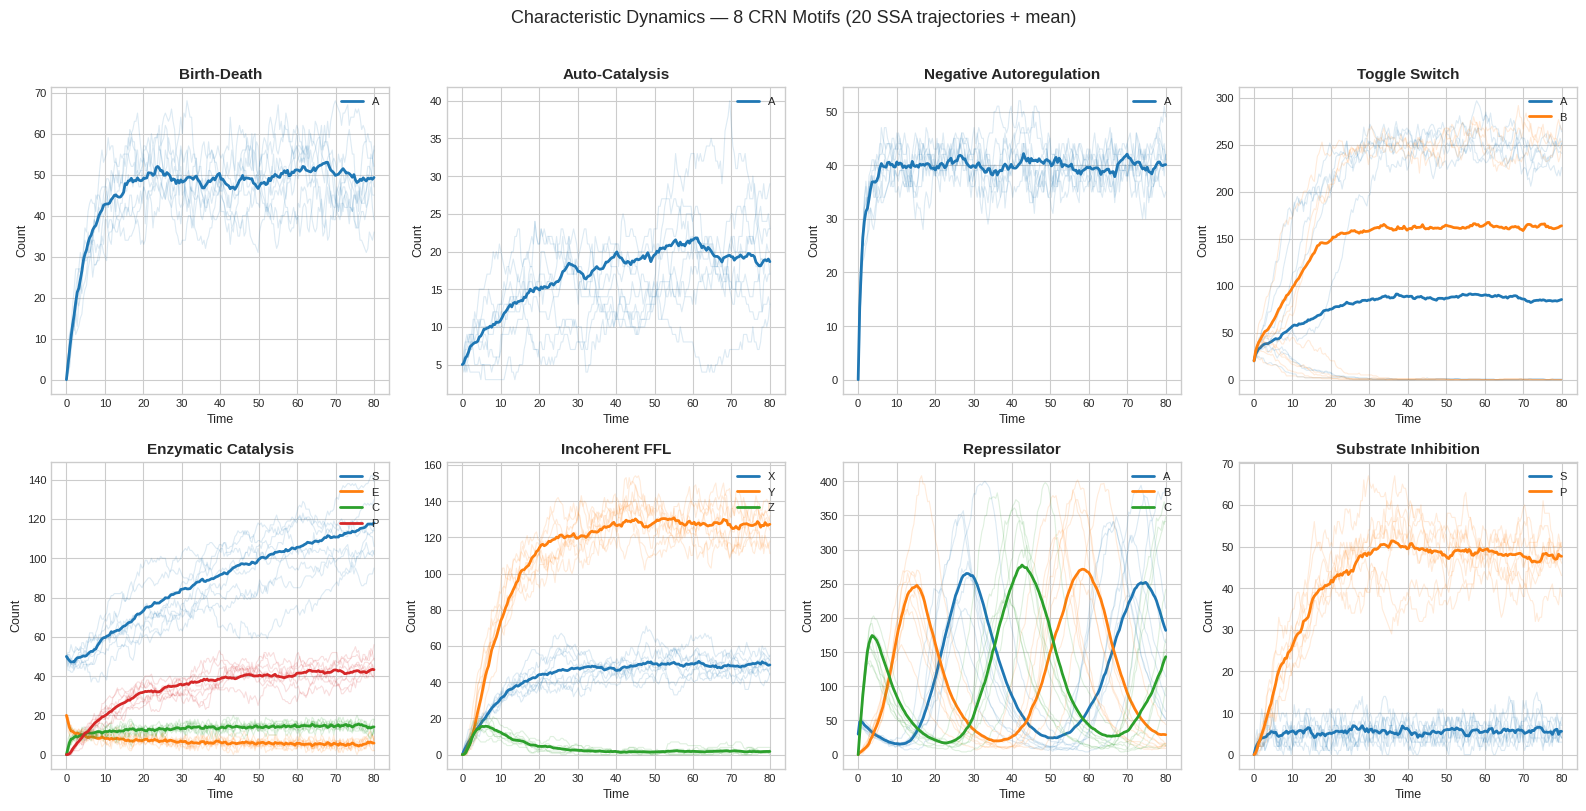

In [5]:
motif_labels = [
    ("birth_death",             "Birth-Death",           ["A"]),
    ("auto_catalysis",          "Auto-Catalysis",         ["A"]),
    ("negative_autoregulation", "Negative Autoregulation",["A"]),
    ("toggle_switch",           "Toggle Switch",          ["A", "B"]),
    ("enzymatic_catalysis",     "Enzymatic Catalysis",    ["S", "E", "C", "P"]),
    ("incoherent_feedforward",  "Incoherent FFL",         ["X", "Y", "Z"]),
    ("repressilator",           "Repressilator",          ["A", "B", "C"]),
    ("substrate_inhibition",    "Substrate Inhibition",   ["S", "P"]),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes_flat = axes.flatten()
t = time_grid.numpy()

for ax, (key, title, species) in zip(axes_flat, motif_labels):
    trajs = all_trajs[key]  # (N, T, n_sp)
    trajs_np = trajs.numpy()
    for sp_idx, sp_name in enumerate(species):
        color = TAB10[sp_idx % 10]
        for i in range(min(8, trajs.shape[0])):
            ax.plot(t, trajs_np[i, :, sp_idx], alpha=0.15, lw=0.8, color=color)
        mean = trajs_np[:, :, sp_idx].mean(axis=0)
        ax.plot(t, mean, color=color, lw=2, label=sp_name)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Time", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(labelsize=8)

plt.suptitle("Characteristic Dynamics — 8 CRN Motifs (20 SSA trajectories + mean)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Notes on each motif:**

- **Birth-death**: Poisson stationary distribution; mean = k_prod/k_deg.
- **Auto-catalysis**: Positive feedback keeps A at a high stable level once seeded.
- **Negative autoregulation**: Hill repression creates a tightly controlled steady state with reduced noise.
- **Toggle switch**: Bistability — from a symmetric initial condition, mutual repression locks one gene on.
- **Enzymatic catalysis**: Complex C forms and turns over; product P accumulates at rate k_cat.
- **Incoherent FFL**: Z shows an early pulse (X activates directly), then settles lower once Y (the repressor) builds up.
- **Repressilator**: Three-node ring oscillator with cooperative repression drives sustained oscillations.
- **Substrate inhibition**: Non-monotone dose-response — product P peaks at intermediate substrate levels.

## 4. Parameter Sampling

The `ParameterSampler` draws kinetic parameters from the ranges defined by each `MotifFactory`:

- **Rate constants** (`k_*`): log-uniform sampling — equal probability per decade
- **Hill coefficients** (`n_*`): uniform sampling — they live in a narrow range (1–5)

Motif-specific constraints (e.g. k_deg > k_cat for auto-catalysis) are enforced by rejection sampling.

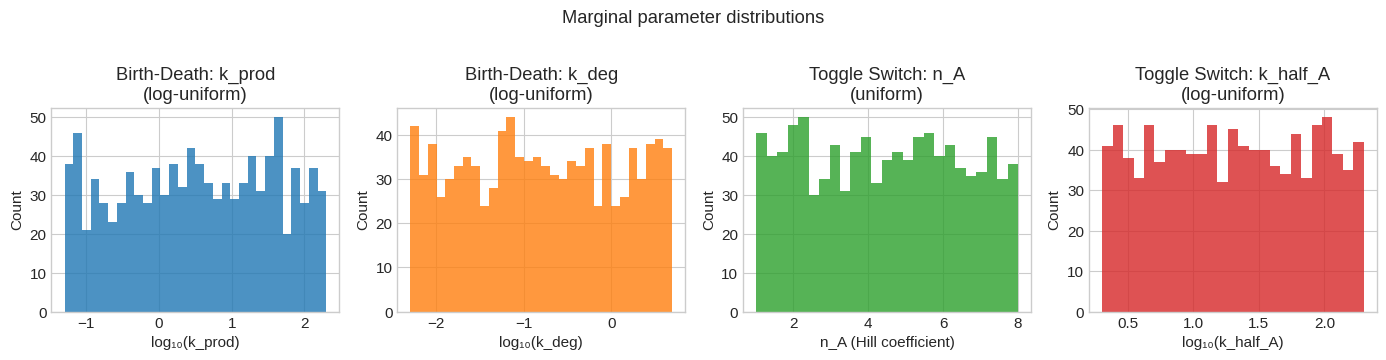

In [6]:
from crn_surrogate.data.generation.parameter_sampling import ParameterSampler
from crn_surrogate.data.generation.configs import SamplingConfig

sampler = ParameterSampler(SamplingConfig(random_seed=0))

bd_params = sampler.sample(BirthDeathFactory(), n_samples=1000)
ts_params = sampler.sample(ToggleSwitchFactory(), n_samples=1000)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

k_prod_vals = [p.k_prod for p in bd_params]
k_deg_vals  = [p.k_deg  for p in bd_params]
axes[0].hist(np.log10(k_prod_vals), bins=30, color=TAB10[0], alpha=0.8)
axes[0].set_xlabel("log\u2081\u2080(k_prod)")
axes[0].set_title("Birth-Death: k_prod\n(log-uniform)")
axes[1].hist(np.log10(k_deg_vals), bins=30, color=TAB10[1], alpha=0.8)
axes[1].set_xlabel("log\u2081\u2080(k_deg)")
axes[1].set_title("Birth-Death: k_deg\n(log-uniform)")

n_A_vals    = [p.n_A     for p in ts_params]
k_half_vals = [p.k_half_A for p in ts_params]
axes[2].hist(n_A_vals, bins=25, color=TAB10[2], alpha=0.8)
axes[2].set_xlabel("n_A (Hill coefficient)")
axes[2].set_title("Toggle Switch: n_A\n(uniform)")
axes[3].hist(np.log10(k_half_vals), bins=25, color=TAB10[3], alpha=0.8)
axes[3].set_xlabel("log\u2081\u2080(k_half_A)")
axes[3].set_title("Toggle Switch: k_half_A\n(log-uniform)")

for ax in axes:
    ax.set_ylabel("Count")
plt.suptitle("Marginal parameter distributions", y=1.02)
plt.tight_layout()
plt.show()

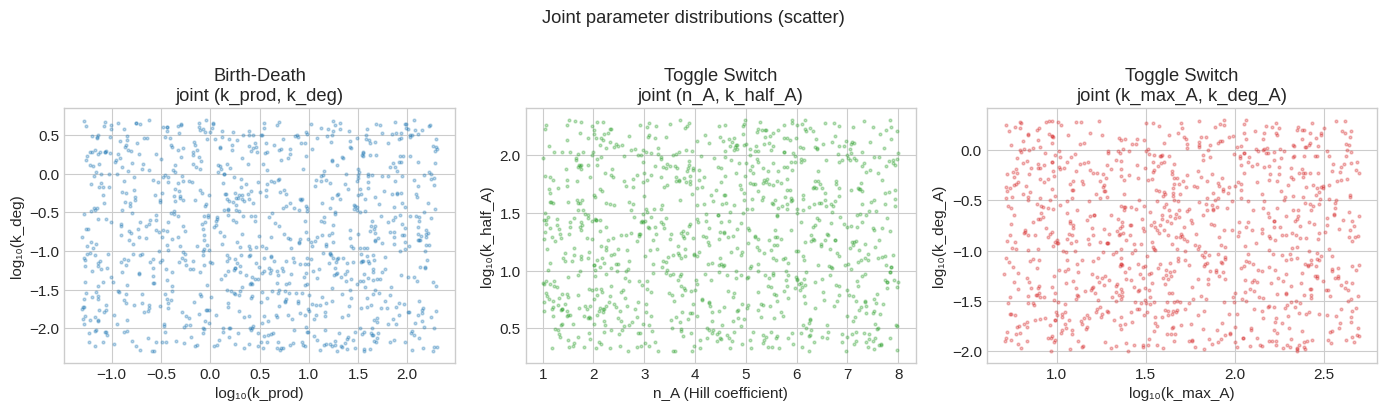

Auto-catalysis constraint violations (k_cat >= k_deg): 0/500
  Mean k_cat: 0.0707
  Mean k_deg: 0.9159


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(np.log10(k_prod_vals), np.log10(k_deg_vals), s=4, alpha=0.3, color=TAB10[0])
axes[0].set_xlabel("log\u2081\u2080(k_prod)")
axes[0].set_ylabel("log\u2081\u2080(k_deg)")
axes[0].set_title("Birth-Death\njoint (k_prod, k_deg)")

axes[1].scatter(n_A_vals, np.log10(k_half_vals), s=4, alpha=0.3, color=TAB10[2])
axes[1].set_xlabel("n_A (Hill coefficient)")
axes[1].set_ylabel("log\u2081\u2080(k_half_A)")
axes[1].set_title("Toggle Switch\njoint (n_A, k_half_A)")

k_max_A_vals = [p.k_max_A for p in ts_params]
k_deg_A_vals = [p.k_deg_A for p in ts_params]
axes[2].scatter(np.log10(k_max_A_vals), np.log10(k_deg_A_vals), s=4, alpha=0.3, color=TAB10[3])
axes[2].set_xlabel("log\u2081\u2080(k_max_A)")
axes[2].set_ylabel("log\u2081\u2080(k_deg_A)")
axes[2].set_title("Toggle Switch\njoint (k_max_A, k_deg_A)")

plt.suptitle("Joint parameter distributions (scatter)", y=1.02)
plt.tight_layout()
plt.show()

# Verify autocatalysis constraint: k_cat < k_deg is required
ac_params = sampler.sample(AutoCatalysisFactory(), n_samples=500)
violations = sum(1 for p in ac_params if p.k_cat >= p.k_deg)
print(f"Auto-catalysis constraint violations (k_cat >= k_deg): {violations}/500")
print(f"  Mean k_cat: {np.mean([p.k_cat for p in ac_params]):.4f}")
print(f"  Mean k_deg: {np.mean([p.k_deg for p in ac_params]):.4f}")

## 5. Viability Curation

Before storing a CRN configuration, the `ViabilityFilter` runs 6 checks on the SSA ensemble:

| Criterion | What it detects |
|-----------|----------------|
| NaN / Inf | Numerical instability |
| Blowup (> 10⁶) | Supercritical growth |
| Zero-stuck (> 95% zeros) | Network never fires |
| Low activity (< 10 transitions) | Network freezes immediately |
| Low CV (< 0.01) | Effectively deterministic — no stochasticity to learn |
| Unbounded final state (> 10⁵ mean) | Slow blowup |

Only configurations passing ALL checks are kept.

In [8]:
from crn_surrogate.data.generation.curation import ViabilityFilter, CurationResult
from crn_surrogate.data.generation.configs import CurationConfig

filt = ViabilityFilter(CurationConfig())

def make_trajs(values):
    """Broadcast a 1D time series to shape (4, T, 1) for curation testing."""
    v = torch.tensor(values, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
    return v.expand(4, -1, -1)

t_grid = torch.linspace(0, 20, 50)

# Simulate a real birth-death trajectory for the "good" case
bd = BirthDeathFactory().create(BirthDeathFactory().params_type(k_prod=10.0, k_deg=0.2))
bd_trajs_list = []
bd_trajectories = ssa.simulate_batch(
    stoichiometry=bd.stoichiometry_matrix,
    propensity_fn=bd.evaluate_propensities,
    initial_state=torch.tensor([0.0]),
    t_max=20.0,
    n_trajectories=4,
    n_workers=1
)
bd_trajs_list.append(Trajectory.stack_on_grid(bd_trajectories, t_grid))
good_trajs = torch.stack(bd_trajs_list)  # (4, 50, 1)

test_cases = [
    ("Good (birth-death)",  good_trajs),
    ("Blowup",              make_trajs([float(i * 1e5) for i in range(50)])),
    ("All zeros",           make_trajs([0.0] * 50)),
    ("Low activity",        make_trajs([10.0] * 50)),
    ("Near-constant",       make_trajs([100.0 + 0.001 * i for i in range(50)])),
    ("Huge final",          make_trajs([i * 4000.0 for i in range(50)])),
]

print(f"{'Test case':<25}  {'Viable?':<8}  Reason")
print("-" * 55)
for name, trajs in test_cases:
    result = filt.check(trajs)
    status = "\u2713 PASS" if result.viable else "\u2717 FAIL"
    print(f"  {name:<23}  {status:<8}  {result.rejection_reason or '\u2014'}")

Test case                  Viable?   Reason
-------------------------------------------------------
  Good (birth-death)       ✓ PASS    —
  Blowup                   ✗ FAIL    blowup
  All zeros                ✗ FAIL    zero_stuck
  Low activity             ✗ FAIL    low_activity
  Near-constant            ✗ FAIL    low_cv
  Huge final               ✗ FAIL    unbounded_final


## Summary

This notebook covered the motif library:

- Five propensity types beyond mass-action: Hill activation/repression, combined activation-repression, substrate inhibition, and Michaelis-Menten
- Eight canonical motifs, each with a typed `MotifFactory` and parameter dataclass
- Log-uniform parameter sampling for rate constants; uniform for Hill coefficients
- Motif-specific constraints enforced by rejection sampling (e.g. k_cat < k_deg for auto-catalysis)
- Six viability criteria that filter degenerate configurations before training data storage